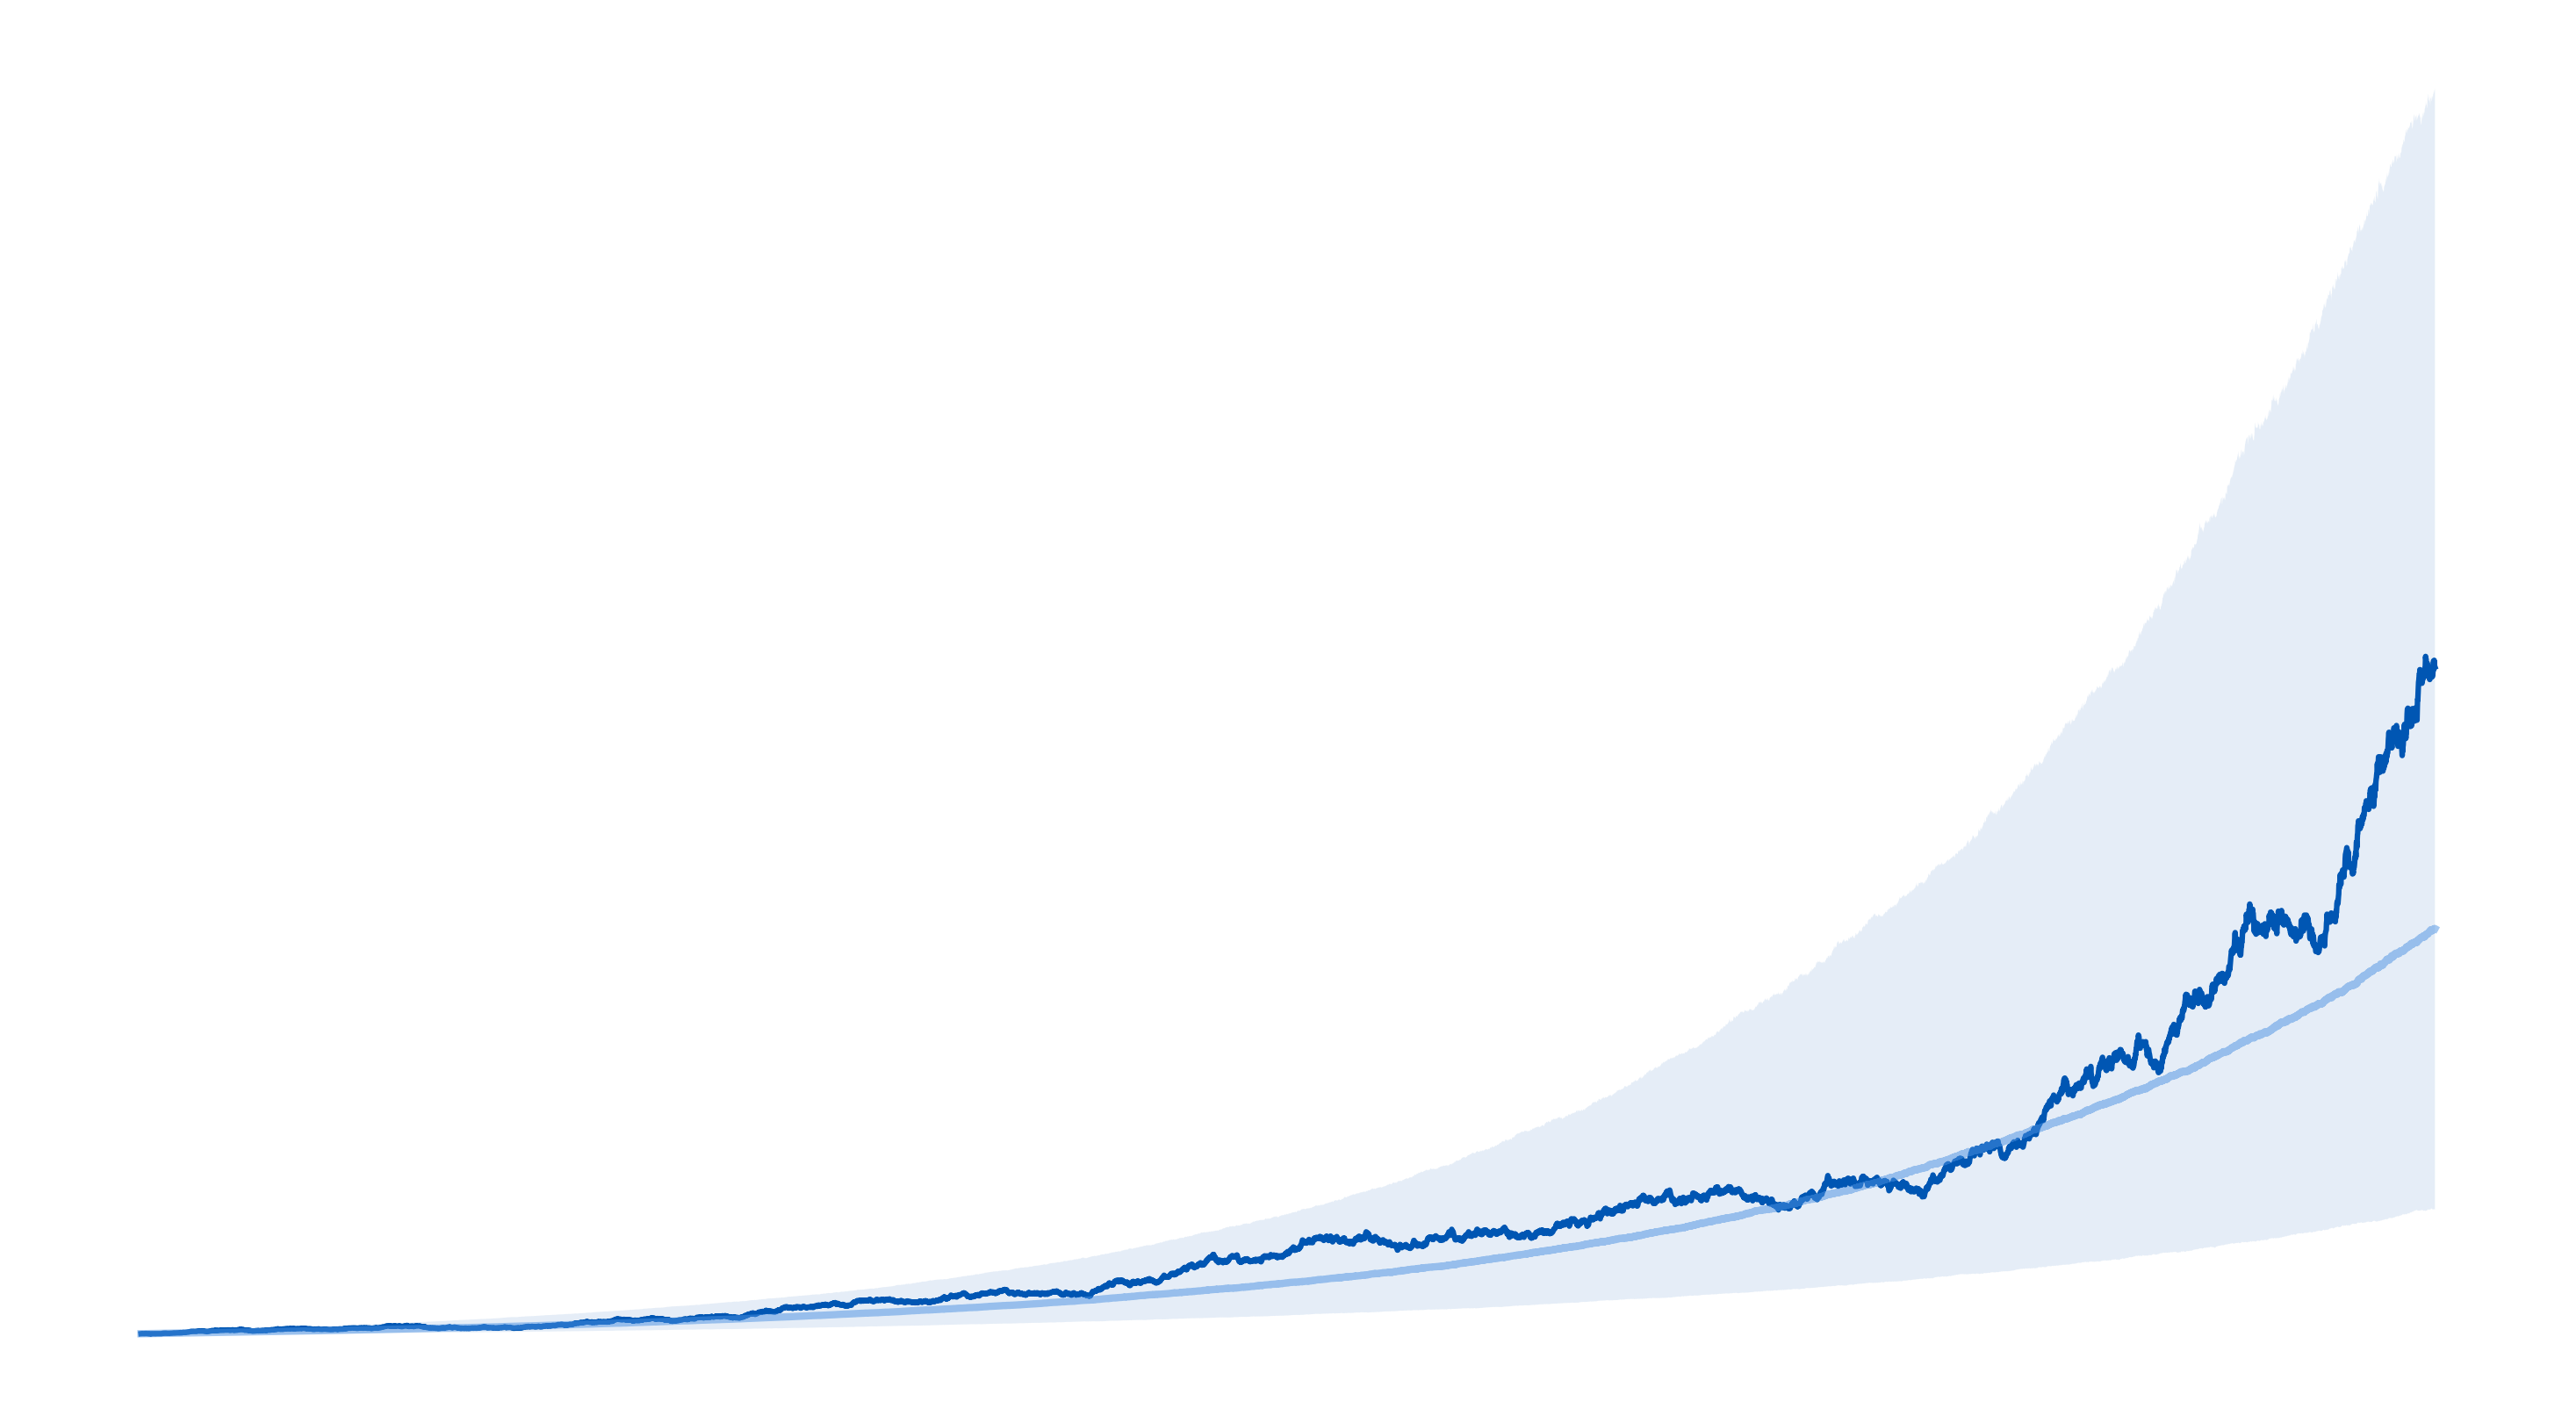

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de Parámetros
# np.random.seed(45) # Semilla para reproducibilidad
S0 = 100          # Precio inicial del activo
mu = 0.1178         # Drift (retorno esperado anual)
sigma = 0.1158      # Volatilidad anualizada (25%)
T = 35.0           # Horizonte de tiempo (1 año)
N_steps = int(252 * T)     # Número de pasos de tiempo (días de trading)
N_sims = 5000     # Número de trayectorias de Montecarlo

dt = T / N_steps
t = np.linspace(0, T, N_steps)

# 2. Generación del Movimiento Browniano (W_t)
# Extraemos variables normales estándar y hacemos una suma acumulativa
W = np.random.standard_normal(size=(N_steps, N_sims))
W = np.cumsum(W, axis=0) * np.sqrt(dt)

# 3. Cálculo de la Simulación usando la Ecuación del GBM
drift = (mu - 0.5 * sigma**2) * t[:, np.newaxis]
diffusion = sigma * W
S = S0 * np.exp(drift + diffusion)

# 4. Cálculos Estadísticos (Montecarlo)
mediana_empirica = np.median(S, axis=1)
std_empirica = np.std(S, axis=1) # Desviación estándar empírica en cada t
banda_sup = np.percentile(S, 95, axis=1) # Banda superior al 95%
banda_inf = np.percentile(S, 5, axis=1)  # Banda inferior al 5%

# 5. Solución Analítica
# OJO: La mediana teórica incluye el arrastre de volatilidad (volatility drag)
mediana_teorica = S0 * np.exp((mu - 0.5 * sigma**2) * t)
import matplotlib.pyplot as plt
from cycler import cycler

def set_figure_style():
    """
    Configures global matplotlib settings optimized for a thesis presentation.
    Adapted for the 'Corporate Blue' theme.
    """
    # Define Corporate Blue theme colors
    text_color = '#1C3B5E'      # Navy Blue for text, ticks, and axes spines
    grid_color = '#F4F7FA'   # Light steel blue for subtle grid lines
    
    # Primary, Secondary, Tertiary blues, and a lighter highlight for plotting data
    theme_colors = ['#0056B3', '#4A90E2', '#00B4D8', '#1C3B5E', '#8ECAE6']

    plt.rcParams.update({
        # Figure properties
        'figure.figsize': (10, 5.625),  # 16:9 aspect ratio fits Google Slides perfectly
        'figure.dpi': 300,              # 300 DPI is ideal for screen presentations
        'figure.facecolor': 'none',     # Transparent background lets the slide's #F4F7FA show
        'axes.facecolor': 'none',       
        'savefig.transparent': True,    
        
        # Font properties (Switched to sans-serif for screen readability)
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'text.color': text_color,
        'axes.labelcolor': text_color,
        'xtick.color': text_color,
        'ytick.color': text_color,
        
        # Increased font sizes for presentation visibility
        'font.size': 14,                
        'axes.titlesize': 18,           
        'axes.labelsize': 16,           
        'xtick.labelsize': 12,          
        'ytick.labelsize': 12,          
        'legend.fontsize': 12,          
        
        # Line, marker, and color cycle properties
        'axes.prop_cycle': cycler(color=theme_colors),
        'lines.linewidth': 2.5,         # Thicker lines for projector visibility
        'lines.markersize': 8,          
        
        # Axes and grid properties
        'axes.linewidth': 1.5,          
        'axes.edgecolor': text_color,   # Binds the axes border to the theme's dark blue
        'axes.grid': True,              
        'grid.color': grid_color,       # Tinted grid instead of default gray/black
        'grid.alpha': 0.6,              
        'grid.linestyle': '--'          
    })

set_figure_style()  # Aplicamos el estilo personalizado

# Graficamos la realización aleatoria (solo la primera columna)
plt.plot(t, S[:, 0], label='Realización Aleatoria', linewidth=1.5, )

# Graficamos la mediana calculada mediante Montecarlo
plt.plot(t, mediana_empirica, linewidth=2, alpha=0.5)

# Graficamos las bandas de confianza de la simulación
plt.fill_between(t, banda_inf, banda_sup, alpha=0.1,label='Bandas (5% - 95%)')



# Graficamos la mediana exacta a partir de la fórmula
# plt.plot(t, mediana_teorica, color='red', linestyle='--', label='Mediana Analítica', linewidth=2)

# Detalles estéticos del gráfico
# plt.title('Simulación de Montecarlo: Movimiento Browniano Geométrico')
# plt.xlabel('Tiempo (Años)')
# plt.ylabel('Precio del Activo ($S_t$)')
# plt.legend(loc='upper left')
# plt.grid(True, alpha=0.3)
# Set axis off
plt.axis('off')
plt.tight_layout()

# Mostrar o guardar el gráfico
plt.show()